# Supervised Learning. Classification
## Task 1. Download data from Don’tGetKicked competition.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [ ]:
train_df = pd.read_csv('data/training.csv', parse_dates=['PurchDate'])
test_df = pd.read_csv('data/test.csv', parse_dates=['PurchDate'])

In [ ]:
display(train_df.head())
display(test_df.head())

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,2009-12-07,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,2009-12-07,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,2009-12-07,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,2009-12-07,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,2009-12-07,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


,RefId,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,73015,2009-12-02,ADESA,2005,4,PONTIAC,GRAND PRIX,Bas,4D SEDAN,SILVER,...,8557.0,9752.0,NaN,NaN,18881,30212,GA,6500.0,0,2152
1,73016,2009-12-02,ADESA,2005,4,CHEVROLET,MALIBU V6,LS,4D SEDAN LS,SILVER,...,7562.0,9296.0,NaN,NaN,18111,30212,GA,6300.0,0,1118
2,73017,2009-12-02,ADESA,2006,3,DODGE,DURANGO 2WD V8,Adv,4D SUV 4.7L ADVENTURER,SILVER,...,15340.0,16512.0,NaN,NaN,18111,30212,GA,9700.0,0,1215
3,73018,2009-12-02,ADESA,2002,7,SATURN,L SERIES,L20,4D SEDAN L200,GOLD,...,5725.0,6398.0,NaN,NaN,18881,30212,GA,4150.0,0,1933
4,73019,2009-12-02,ADESA,2007,2,HYUNDAI,ACCENT,GS,2D COUPE GS,BLUE,...,5914.0,7350.0,NaN,NaN,18111,30212,GA,4100.0,0,920


In [ ]:
cat_columns = train_df.select_dtypes(include='object').columns
num_columns = train_df.drop(['IsBadBuy', 'RefId'], axis=1).select_dtypes(include=['int64', 'float64']).columns

train_df[cat_columns] = train_df[cat_columns].fillna(train_df[cat_columns].mode().loc[0])
train_df[num_columns] = train_df[num_columns].fillna(train_df[num_columns].median())

test_df[cat_columns] = test_df[cat_columns].fillna(test_df[cat_columns].mode().loc[0])
test_df[num_columns] = test_df[num_columns].fillna(test_df[num_columns].median())

## Task 2. Design the train/validation/test split.
Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [ ]:
train_df = train_df.sort_values(by='PurchDate')

In [ ]:
train_date = train_df.PurchDate.unique()[172]
valid_date = train_df.PurchDate.unique()[344]

print(train_date, valid_date)

2009-09-02 00:00:00 2010-05-03 00:00:00


In [ ]:
train = train_df[train_df['PurchDate'] <= train_date]
valid = train_df[(train_df['PurchDate'] > train_date) & (train_df['PurchDate'] <= valid_date)]
test = train_df[train_df['PurchDate'] > valid_date]

In [ ]:
X_train, y_train = train.drop('IsBadBuy', axis=1), train['IsBadBuy']
X_valid, y_valid = valid.drop('IsBadBuy', axis=1), valid['IsBadBuy']
X_test, y_test = test.drop('IsBadBuy', axis=1), test['IsBadBuy']

## Task 3. Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables.
Be careful with data leakage (fit Encoder to training and apply to validation & test). Consider another coding approach if you encounter new categorical values in validation & test (not seen in training): https://contrib.scikit-learn.org/category_encoders/count.html

In [ ]:
cat_columns = X_train.select_dtypes(include='object').columns
num_columns = X_train.drop('RefId', axis=1).select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_columns)
  ], verbose_feature_names_out=False)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 6, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 12, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Task 4. Train LogisticRegression, GaussianNB, KNN from sklearn on the training dataset and check the quality of your algorithms on the validation dataset.
The dependent variable (IsBadBuy) is binary. Don't forget to normalize your datasets before training your models.

You must get at least 0.15 Gini score (the best of all three). Which algorithm performs better? And why?

In [ ]:
def gini_score(y_true, y_pred_proba):
    """
    Gini = 2 * AUC - 1
    """
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    return gini, auc

In [ ]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        random_state=21,
        penalty='elasticnet',
        solver='saga',
        C=0.1,
        l1_ratio=0.5,
        class_weight='balanced'
    ),
    'GaussianNB': GaussianNB(),
    'KNN': KNeighborsClassifier(
        n_neighbors=6,
        weights='uniform'
    )
}

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_pred_train = model.predict(X_train_processed)
    y_pred_valid = model.predict(X_valid_processed)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    valid_accuracy = accuracy_score(y_valid, y_pred_valid)

    y_pred_proba_train = model.predict_proba(X_train_processed)[:, 1]
    y_pred_proba_valid = model.predict_proba(X_valid_processed)[:, 1]

    train_gini = gini_score(y_train, y_pred_proba_train)
    valid_gini = gini_score(y_valid, y_pred_proba_valid)

    results[name] = {
        'train_accuracy': train_accuracy,
        'val_accuracy': valid_accuracy,
        'train_gini': train_gini[0],
        'valid_gini': valid_gini[0]
    }

display(pd.DataFrame(results))

Логистическая регрессия работает лучше всего, потому что этот алгоритм очень хорошо работает с OHE признаками, использует регуляризацию для предотвращения переобучения.

Гаусс не работает, потому что распределение признаков после OHE не нормальное, признаки становятся сильно зависимы длруг от друга.

KNN работает плохо, потому что очень большое пространство признаков, евклидовы расстояния почти одинаковы, из-за того, что большинство объектов 0, то признаки выглядят одинаково разреженными

## Task 5. Implement Gini score calculation.
You can use the 2*ROC AUC - 1 approach, so you need to implement the ROC AUC calculation. Check if your metric is approximately equal to abs(2*sklearn.metrics.roc_auc_score - 1).


In [ ]:
def my_roc_auc_score(y_true, y_pred_proba):
    sorted_indices = np.argsort(y_pred_proba)[::-1]
    y_true_sorted = y_true[sorted_indices]
    y_pred_sorted = y_pred_proba[sorted_indices]

    tpr_list = [0]
    fpr_list = [0]

    total_positives = np.sum(y_true == 1)
    total_negatives = np.sum(y_true == 0)

    tp = 0
    fp = 0


    for i in range(len(y_true_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1

        tpr = tp / total_positives if total_positives > 0 else 0
        fpr = fp / total_negatives if total_negatives > 0 else 0

        tpr_list.append(tpr)
        fpr_list.append(fpr)


    auc = np.trapz(tpr_list, fpr_list)

    return auc


def my_gini_score(y_true, y_pred_proba):
    """
    Gini = 2 * AUC - 1
    """
    auc = my_roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    return gini, auc

In [ ]:
for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_pred_train = model.predict(X_train_processed)
    y_pred_valid = model.predict(X_valid_processed)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    valid_accuracy = accuracy_score(y_valid, y_pred_valid)

    y_pred_proba_train = model.predict_proba(X_train_processed)[:, 1]
    y_pred_proba_valid = model.predict_proba(X_valid_processed)[:, 1]

    train_gini = my_gini_score(y_train.values, y_pred_proba_train)
    valid_gini = my_gini_score(y_valid.values, y_pred_proba_valid)

    results[name + '_my_roc_auc'] = {
        'train_accuracy': train_accuracy,
        'val_accuracy': valid_accuracy,
        'train_gini': train_gini[0],
        'valid_gini': valid_gini[0]
    }

display(pd.DataFrame(results))

/tmp/ipykernel_4671/1909196193.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr_list, fpr_list)
/tmp/ipykernel_4671/1909196193.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr_list, fpr_list)
/tmp/ipykernel_4671/1909196193.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr_list, fpr_list)


,LogisticRegression,GaussianNB,KNN,LogisticRegression_my_roc_auc,GaussianNB_my_roc_auc,KNN_my_roc_auc
train_accuracy,0.658048,0.190978,0.891562,0.658048,0.190978,0.891562
val_accuracy,0.713438,0.466594,0.866126,0.713438,0.466594,0.866126
train_gini,0.447619,0.087621,0.739457,0.447619,0.078145,0.737570
valid_gini,0.345441,0.055853,0.195497,0.345441,0.067959,0.201838


## Task 6. Implement your own versions of LogisticRegression, KNN and NaiveBayes classifiers.
For LogisticRegression compute gradients with respect to the loss and use stochastic gradient descent. Can you reproduce the results from step 4?

Guidance for this task: Your model must be represented by class with methods fit, predict (predict_proba with 0.5 threshold), predict_proba. For LR moder, compute the loss gradient with respect to parameters w and parameter b in the fit function. Use a simple SGD approach to estimate optimal values of parameters.


In [ ]:
class MyGaussianNaiveBayes:

    def __init__(self):

        self.classes = None

        self.priors = {}
        self.means = {}
        self.vars = {}

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        self.classes = np.unique(y)

        for c in self.classes:

            X_c = X[y == c]

            self.priors[c] = len(X_c) / len(X)

            self.means[c] = np.mean(X_c, axis=0)
            self.vars[c] = np.var(X_c, axis=0) + 1e-9

    def predict_proba(self, X):

        X = np.array(X, dtype=np.float64)

        results = []

        for x in X:

            class_scores = []

            for c in self.classes:

                mean = self.means[c]
                var = self.vars[c]

                log_prob = np.log(self.priors[c])

                log_likelihood = -0.5 * np.sum(
                    np.log(2 * np.pi * var)
                    +
                    ((x - mean) ** 2) / var
                )

                class_scores.append(
                    log_prob + log_likelihood
                )

            class_scores = np.array(class_scores)

            exp_scores = np.exp(
                class_scores - np.max(class_scores)
            )

            probs = exp_scores / np.sum(exp_scores)

            results.append(probs)

        return np.array(results)

    def predict(self, X):

        probs = self.predict_proba(X)

        class_indices = np.argmax(
            probs,
            axis=1
        )

        return self.classes[class_indices]

In [ ]:
class MyLogisticRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

    def sigmoid(self, z):

        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):

            z = np.dot(X, self.weights) + self.bias

            predictions = self.sigmoid(z)

            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))

            db = (1 / n_samples) * np.sum(predictions - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):

        X = np.array(X)

        z = np.dot(X, self.weights) + self.bias

        prob_class_1 = self.sigmoid(z)

        prob_class_0 = 1 - prob_class_1

        return np.column_stack(
            (prob_class_0, prob_class_1)
        )

    def predict(self, X):

        probs = self.predict_proba(X)

        return np.argmax(probs, axis=1)

In [ ]:
class MyKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(
            X,
            dtype=np.float32
        )

        self.y_train = np.array(y)

    def predict_proba(self, X):

      X = np.array(X, dtype=np.float32)

      probs = []

      for x in X:

          distances = np.sum(
              (self.X_train - x) ** 2,
              axis=1
          )

          k_idx = np.argpartition(
              distances,
              self.k
          )[:self.k]

          k_labels = self.y_train[k_idx]

          prob_class_1 = np.mean(k_labels)

          prob_class_0 = 1 - prob_class_1

          probs.append([
              prob_class_0,
              prob_class_1
          ])

      return np.array(probs)

    def predict(self, X):
       probs = self.predict_proba(X)

       return np.argmax(probs, axis=1)

In [ ]:
models = {'MyLogisticRegression': MyLogisticRegression(),
    'MyGaussianNB': MyGaussianNaiveBayes(),
    'MyKNN': MyKNN(k=3),
}

In [ ]:
results = pd.read_csv('data/custom_models.csv', index_col='Unnamed: 0')

In [ ]:
results = results.to_dict()

In [ ]:
for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_pred_proba_valid = model.predict_proba(X_valid_processed)[:, 1]

    y_pred_valid = (y_pred_proba_valid >= 0.5).astype(int)

    valid_accuracy = accuracy_score(y_valid, y_pred_valid)

    valid_gini = gini_score(y_valid, y_pred_proba_valid)

    results[name] = {
        'train_accuracy': 0,
        'val_accuracy': valid_accuracy,
        'train_gini': 0,
        'valid_gini': valid_gini[0]
    }

display(pd.DataFrame(results))

,MyLogisticRegression,MyGaussianNB,MyKNN
train_accuracy,0.886716,0.190978,0.000000
val_accuracy,0.867338,0.466594,0.851827
train_gini,0.355951,0.087621,0.000000
valid_gini,0.324537,0.055853,0.142623


In [ ]:
pd.DataFrame(results).to_csv('data/custom_models.csv', index=True)

## Task 7. Try to create non-linear features, for example:

fractions: feature1/feature2

groupby features: df[‘categorical_feature’].map(df.groupby(‘categorical_feature’)[‘continious_feature’].mean())

Add new features to your pipeline, repeat step 4. Did you manage to increase your Gini score (you should!)?

In [ ]:
train_df.columns

Index(['RefId', 'IsBadBuy', 'PurchDate', 'Auction', 'VehYear', 'VehicleAge',
       'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission',
       'WheelTypeID', 'WheelType', 'VehOdo', 'Nationality', 'Size',
       'TopThreeAmericanName', 'MMRAcquisitionAuctionAveragePrice',
       'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice',
       'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice',
       'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice',
       'MMRCurrentRetailCleanPrice', 'PRIMEUNIT', 'AUCGUART', 'BYRNO',
       'VNZIP1', 'VNST', 'VehBCost', 'IsOnlineSale', 'WarrantyCost'],
      dtype='object')

In [ ]:
eps = 1e-9
train_df['CostRetailRatio'] = train_df['VehBCost'] /(train_df['MMRCurrentRetailAveragePrice'] + eps) #actual cost / MMR price
train_df['OdoPerYear'] = train_df['VehOdo'] /(train_df['VehicleAge'] + 1) #пробег за год
train_df['AuctionProfit'] = train_df['MMRCurrentAuctionAveragePrice'] - train_df['VehBCost'] #MMR price vs actual cost
train_df['AuctionPriceChange'] = train_df['MMRCurrentAuctionAveragePrice']- train_df['MMRAcquisitionAuctionAveragePrice'] # разница в цене с течением времени
train_df['WarrantyRatio'] = train_df['WarrantyCost'] /(train_df['VehBCost'] + eps) #отношение гарантированной цены к актуальной
train_df['RetailDepreciationRatio'] = train_df['MMRCurrentRetailAveragePrice']/(train_df['MMRAcquisitionRetailAveragePrice']+ 1) # скорость падения цены
make_mean_price = train_df.groupby('Make')['VehBCost'].mean()

train_df['make_mean_price'] = train_df['Make'].map(make_mean_price) # средняя цена по производителю

make_odo_mean = train_df.groupby('Make')['VehOdo'].mean()

train_df['OdoRelativeToMake'] = train_df['VehOdo'] / train_df['Make'].map(make_odo_mean) # средний пробег по производителю

In [ ]:
train = train_df[train_df['PurchDate'] <= train_date]
valid = train_df[(train_df['PurchDate'] > train_date) & (train_df['PurchDate'] <= valid_date)]
test = train_df[train_df['PurchDate'] > valid_date]

X_train, y_train = train.drop('IsBadBuy', axis=1), train['IsBadBuy']
X_valid, y_valid = valid.drop('IsBadBuy', axis=1), valid['IsBadBuy']
X_test, y_test = test.drop('IsBadBuy', axis=1), test['IsBadBuy']

In [ ]:
cat_columns = X_train.select_dtypes(include='object').columns
num_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_columns)
  ], verbose_feature_names_out=False)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 6, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 12, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_pred_train = model.predict(X_train_processed)
    y_pred_valid = model.predict(X_valid_processed)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    valid_accuracy = accuracy_score(y_valid, y_pred_valid)

    y_pred_proba_train = model.predict_proba(X_train_processed)[:, 1]
    y_pred_proba_valid = model.predict_proba(X_valid_processed)[:, 1]

    train_gini = gini_score(y_train, y_pred_proba_train)
    valid_gini = gini_score(y_valid, y_pred_proba_valid)

    results[name] = {
        'train_accuracy': train_accuracy,
        'val_accuracy': valid_accuracy,
        'train_gini': train_gini[0],
        'valid_gini': valid_gini[0]
    }

display(pd.DataFrame(results))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,LogisticRegression,GaussianNB,KNN
train_accuracy,0.657962,0.191150,0.891990
val_accuracy,0.707166,0.468601,0.865499
train_gini,0.445540,0.087814,0.737351
valid_gini,0.345240,0.055643,0.202987


## Task 8. Determine the best features for the problem using the coefficients of the logistic model.
Try to eliminate useless features by hand and by L1 regularization. Which approach is better in terms of Gini score?

In [ ]:
my_delete_cols = ['RefId','Auction', 'PRIMEUNIT', 'AUCGUART', 'WheelTypeID', 'VehYear', 'BYRNO']

In [ ]:
model = LogisticRegression(
  max_iter=1000,
  random_state=21,
  penalty='l1',
  solver='saga',
  C=0.1,
  class_weight='balanced'
)

In [ ]:
model.fit(X_train_processed, y_train)

coefs = model.coef_

In [ ]:
feature_names = preprocessor.get_feature_names_out()

top_features = pd.DataFrame({
    'feature': feature_names,
    'weight': np.abs(coefs[0])}).sort_values('weight')

In [ ]:
zero_features = top_features[top_features['weight'] == 0].feature.to_list()

cols= [x.split('_')[0] for x in zero_features]
uniques = set(cols)

counts = {u: cols.count(u) for u in uniques}

In [ ]:
counts

{'MMRCurrentAuctionAveragePrice': 1,
 'PRIMEUNIT': 1,
 'Size': 3,
 'MMRAcquisitionAuctionCleanPrice': 1,
 'WheelType': 1,
 'SubModel': 627,
 'MMRCurrentRetailAveragePrice': 1,
 'Trim': 104,
 'MMRAcquisitonRetailCleanPrice': 1,
 'Model': 764,
 'Make': 24,
 'MMRCurrentAuctionCleanPrice': 1,
 'Color': 7,
 'MMRAcquisitionRetailAveragePrice': 1,
 'VehicleAge': 1,
 'VNST': 12,
 'IsOnlineSale': 1,
 'Nationality': 2}

In [ ]:
l1_delete_cols = ['RefId','MMRCurrentAuctionAveragePrice', 'PRIMEUNIT',
                  'MMRAcquisitionAuctionCleanPrice','SubModel',
                  'MMRCurrentRetailAveragePrice','Trim','MMRAcquisitonRetailCleanPrice',
                  'Model', 'Make', 'MMRCurrentAuctionCleanPrice', 'Color',
                  'MMRAcquisitionRetailAveragePrice','VNST', 'IsOnlineSale']

### My delete cols

In [ ]:
my_delete_train = X_train.drop(my_delete_cols, axis=1)
my_delete_valid = X_valid.drop(my_delete_cols, axis=1)
my_delete_test = X_test.drop(my_delete_cols, axis=1)

In [ ]:
cat_columns = my_delete_train.select_dtypes(include='object').columns
num_columns = my_delete_train.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_columns)
  ], verbose_feature_names_out=False)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 5, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
model.fit(X_train_processed, y_train)

y_pred_train = model.predict(X_train_processed)
y_pred_valid = model.predict(X_valid_processed)

train_accuracy = accuracy_score(y_train, y_pred_train)
valid_accuracy = accuracy_score(y_valid, y_pred_valid)

y_pred_proba_train = model.predict_proba(X_train_processed)[:, 1]
y_pred_proba_valid = model.predict_proba(X_valid_processed)[:, 1]

train_gini = gini_score(y_train, y_pred_proba_train)
valid_gini = gini_score(y_valid, y_pred_proba_valid)

In [ ]:
print('My delete columns')
print(f'train_accuracy {valid_accuracy}')
print(f'val_accuracy {train_accuracy}')
print(f'train_gini {train_gini[0]}')
print(f'valid_gini {valid_gini[0]}')

My delete columns
train_accuracy 0.6989296763943473
val_accuracy 0.6516164994425864
train_gini 0.4168441058514665
valid_gini 0.35076199163874944


Gini улучшился

### L1 delete columns

In [ ]:
l1_delete_train = X_train.drop(l1_delete_cols, axis=1)
l1_delete_valid = X_valid.drop(l1_delete_cols, axis=1)


cat_columns = l1_delete_train.select_dtypes(include='object').columns
num_columns = l1_delete_valid.drop(['RefId'], axis=1).select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_columns)
  ], verbose_feature_names_out=False)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

model.fit(X_train_processed, y_train)

y_pred_train = model.predict(X_train_processed)
y_pred_valid = model.predict(X_valid_processed)

train_accuracy = accuracy_score(y_train, y_pred_train)
valid_accuracy = accuracy_score(y_valid, y_pred_valid)

y_pred_proba_train = model.predict_proba(X_train_processed)[:, 1]
y_pred_proba_valid = model.predict_proba(X_valid_processed)[:, 1]

train_gini = gini_score(y_train, y_pred_proba_train)
valid_gini = gini_score(y_valid, y_pred_proba_valid)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
print('L1 delete columns')
print(f'train_accuracy {valid_accuracy}')
print(f'val_accuracy {train_accuracy}')
print(f'train_gini {train_gini[0]}')
print(f'valid_gini {valid_gini[0]}')

L1 delete columns
train_accuracy 0.7296596705410151
val_accuracy 0.636780722065003
train_gini 0.3816410476794292
valid_gini 0.3307320587352145


Gini стал хуже

## Task 9. Select your best model (algorithm + feature set) and tweak its hyperparameters to increase the Gini score on the validation dataset.
Which hyperparameters have the most impact?

In [ ]:
%pip install optuna

In [ ]:
import optuna
from optuna.samplers import TPESampler

In [ ]:
model = LogisticRegression(
  max_iter=1000,
  random_state=21,
  penalty='l1',
  solver='saga',
  C=0.1,
  class_weight='balanced'
)

In [ ]:
def objective(trial, X_train, y_train, X_val, y_val):
  C = trial.suggest_float('C', 0.001, 1, log=True)
  l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)


  model = LogisticRegression(
    max_iter=1000,
    random_state=21,
    penalty='elasticnet',
    solver='saga',
    C=C,
    l1_ratio=l1_ratio,
    class_weight='balanced',
    n_jobs=-1
  )


  model.fit(X_train, y_train)

  y_proba = model.predict_proba(X_val)[:, 1]

  return gini_score(y_val, y_proba)[0]

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=21)
)

study.optimize(
    lambda trial: objective(trial, X_train_processed, y_train, X_valid_processed, y_valid),
    n_trials=100,
    show_progress_bar=True
)

[I 2026-05-25 16:38:38,701] A new study created in memory with name: no-name-ea1cf769-c43a-4ff6-b3a7-0b6881302aa8


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-25 16:38:47,594] Trial 0 finished with value: 0.3235203908125448 and parameters: {'C': 0.0014001502504701327, 'l1_ratio': 0.28910965978981684}. Best is trial 0 with value: 0.3235203908125448.
[I 2026-05-25 16:42:56,331] Trial 1 finished with value: 0.3273850366018354 and parameters: {'C': 0.1455120772456994, 'l1_ratio': 0.021616249915949792}. Best is trial 1 with value: 0.3273850366018354.
[I 2026-05-25 16:43:09,176] Trial 2 finished with value: 0.3463073472494065 and parameters: {'C': 0.0041473271596757285, 'l1_ratio': 0.0507732566953768}. Best is trial 2 with value: 0.3463073472494065.
[I 2026-05-25 16:43:30,616] Trial 3 finished with value: 0.335883684167229 and parameters: {'C': 0.008068925058345685, 'l1_ratio': 0.6639102946247}. Best is trial 2 with value: 0.3463073472494065.
[I 2026-05-25 16:43:58,860] Trial 4 finished with value: 0.33685281566106284 and parameters: {'C': 0.008401235903641736, 'l1_ratio': 0.5835912762185987}. Best is trial 2 with value: 0.3463073472494

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-05-25 16:54:07,508] Trial 8 finished with value: 0.3476433364575793 and parameters: {'C': 0.1891609587474209, 'l1_ratio': 0.9704851253491577}. Best is trial 8 with value: 0.3476433364575793.
[I 2026-05-25 17:00:38,991] Trial 9 finished with value: 0.34138588143194526 and parameters: {'C': 0.18963026779504902, 'l1_ratio': 0.3842500320901294}. Best is trial 8 with value: 0.3476433364575793.


...

[I 2026-05-25 17:30:29,571] Trial 17 finished with value: 0.27776775861831915 and parameters: {'C': 0.9598286946991353, 'l1_ratio': 0.5337821228593371}. Best is trial 15 with value: 0.3523679436423419.
[I 2026-05-25 17:32:59,545] Trial 18 finished with value: 0.3528857192187913 and parameters: {'C': 0.07491450039679912, 'l1_ratio': 0.39535844462616654}. Best is trial 18 with value: 0.3528857192187913.
[I 2026-05-25 17:33:22,269] Trial 19 finished with value: 0.34616934263299703 and parameters: {'C': 0.012530331049810939, 'l1_ratio': 0.3311140204816946}. Best is trial 18 with value: 0.3528857192187913.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-05-25 17:42:25,628] Trial 20 finished with value: 0.2912107512341453 and parameters: {'C': 0.46483009691007965, 'l1_ratio': 0.17785729150946789}. Best is trial 18 with value: 0.3528857192187913.
[I 2026-05-25 17:45:05,395] Trial 21 finished with value: 0.3525943052434539 and parameters: {'C': 0.07809382335918735, 'l1_ratio': 0.4338339747994427}. Best is trial 18 with value: 0.3528857192187913.
[I 2026-05-25 17:47:56,549] Trial 22 finished with value: 0.3524147047838335 and parameters: {'C': 0.07828541846133953, 'l1_ratio': 0.46092127580219777}. Best is trial 18 with value: 0.3528857192187913.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-05-25 17:56:54,265] Trial 23 finished with value: 0.3336151763147983 and parameters: {'C': 0.2849033596309694, 'l1_ratio': 0.41958956889195786}. Best is trial 18 with value: 0.3528857192187913.
[I 2026-05-25 17:57:28,219] Trial 24 finished with value: 0.35256155117553445 and parameters: {'C': 0.01769967442932654, 'l1_ratio': 0.24889105601280934}. Best is trial 18 with value: 0.3528857192187913.
[I 2026-05-25 17:58:04,948] Trial 25 finished with value: 0.3535038838865252 and parameters: {'C': 0.01965175777951797, 'l1_ratio': 0.23353976145406863}. Best is trial 25 with value: 0.3535038838865252.
[I 2026-05-25 17:58:42,509] Trial 26 finished with value: 0.35445104767061375 and parameters: {'C': 0.018577425209091895, 'l1_ratio': 0.16726583873809184}. Best is trial 26 with value: 0.35445104767061375.
[I 2026-05-25 17:59:19,595] Trial 27 finished with value: 0.35494311829209124 and parameters: {'C': 0.017456873022921364, 'l1_ratio': 0.11733091751943281}. Best is trial 27 with value: 

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    random_state=21,
    penalty='elasticnet',
    solver='saga',
    C=0.016,
    l1_ratio=0.0008,
    class_weight='balanced',
    n_jobs=-1
  )

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

gini = gini_score(y_test, y_proba)[0]
acc = accuracy_score(y_test, y_pred)

print(f'gini: {gini}')
print(f'accuracy: {acc}')

gini: 0.3657579641348425
accuracy: 0.6865167229926582


Больше всего влияет именно гиперпараметр С, потому что в обучающих данных очень много категориальных признаков и модель начинает переобучаться, сильная регуляризация при низком С очень сильно влияет на gini.

## Task 10. Check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini.
Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitted or not? Explain.

In [ ]:
results = {}

y_proba_train = model.predict_proba(X_train_processed)[:, 1]
y_proba_valid = model.predict_proba(X_valid_processed)[:, 1]

results['train'] = {'gini_score': gini_score(y_train, y_proba_train)[0]}
results['valid'] = {'gini_score': gini_score(y_valid, y_proba_valid)[0]}
results['test'] = {'gini_score': gini_score(y_test, y_proba)[0]}

display(pd.DataFrame(results))

,train,valid,test
gini_score,0.432661,0.358595,0.365758


Model is not overfitted

## Task 11. Implement calculation of Recall, Precision, F1 score and AUC PR metrics.
Compare your algorithms on the test dataset using AUC PR metric.

### Precison

In [ ]:
def precision_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
  eps = 1e-9
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)

  tp = np.sum((y_true == 1) & (y_pred == 1))

  fp = np.sum((y_true == 0) & (y_pred == 1))

  return tp / (tp + fp + eps)

### Recall

In [ ]:
def recall_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
  eps = 1e-9
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)

  tp = np.sum((y_true == 1) & (y_pred == 1))

  fn = np.sum((y_true == 1) & (y_pred == 0))

  return tp / (tp + fn + eps)

### F1 score

In [ ]:
def f1_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
  eps = 1e-9
  precision = precision_score( y_true, y_pred)

  recall = recall_score(y_true, y_pred)

  return 2 * (precision * recall / (precision + recall + eps))

### AUC PR metric

In [ ]:
def precision_recall(y_true: np.ndarray,
                     y_scores: np.ndarray,
                     thresholds: np.ndarray = np.linspace(0, 1, 100)
                     ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
  precisions = []
  recalls = []

  for threshold in thresholds:

    y_pred = (y_scores >= threshold).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    precisions.append(precision)
    recalls.append(recall)

  return np.array(recalls), np.array(precisions), thresholds

In [ ]:
def auc_pr_score(y_true: np.ndarray, y_scores: np.ndarray) -> float:

  recalls, precisions, _ = precision_recall(y_true, y_scores)

  order = np.argsort(recalls)

  recalls = recalls[order]
  precisions = precisions[order]

  auc = np.trapz(precisions, recalls)

  return auc

### Compare algorithms

#### Data preprocessing

In [ ]:
filtred_train = X_train.drop(my_delete_cols, axis=1)
filtered_test = X_test.drop(my_delete_cols, axis=1)

cat_columns = filtred_train.select_dtypes(include='object').columns
num_columns = filtred_train.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_columns)
  ], verbose_feature_names_out=False)

X_train_processed = preprocessor.fit_transform(filtred_train)
X_test_processed = preprocessor.transform(filtered_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        random_state=21,
        penalty='elasticnet',
        solver='saga',
        C=0.016,
        l1_ratio=0.0008,
        class_weight='balanced',
        n_jobs=-1
    ),
    'GaussianNB': GaussianNB(),
    'KNN': KNeighborsClassifier(
        n_neighbors=6,
        weights='uniform'
    )
}

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

    results[name] = {
        'test_auc_pr': auc_pr_score(y_test, y_pred_proba)
    }

display(pd.DataFrame(results))

/tmp/ipykernel_7650/1702810742.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(precisions, recalls)
/tmp/ipykernel_7650/1702810742.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(precisions, recalls)
/tmp/ipykernel_7650/1702810742.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(precisions, recalls)


,LogisticRegression,GaussianNB,KNN
test_auc_pr,0.235437,0.070394,0.189027


## Task 12. Which hard label metric do you prefer for the task of detecting "lemon" cars?

F1 score. В данной задаче важно минимизировать количество ложноотрицательных ошибок (False Negatives), то есть случаев, когда проблемный автомобиль классифицируется как качественный, поскольку такие ошибки приводят к прямым финансовым потерям.
Поэтому важной метрикой является Recall, отражающий долю корректно обнаруженных проблемных автомобилей.

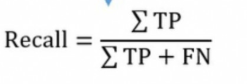

Однако оптимизация только Recall может ухудшить Precision и увеличить число ложноположительных предсказаний.

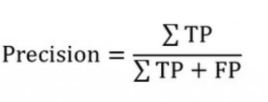

Поэтому для данной задачи более подходящей метрикой является F1-score, который учитывает баланс между Precision и Recall:
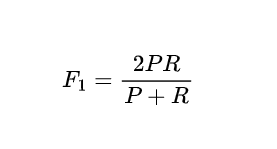

Картинки:
https://habr.com/ru/articles/661119/ Recall, Precision
https://habr.com/ru/articles/1038730/ - F1